In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

# Set plotting parameters
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)
sc.settings.verbosity = 3

# Load your data (adjust this to your data loading method)
# adata = sc.read('your_data.h5ad')  # or however you load your data

def prepare_data_for_pseudotime(adata):
    """
    Prepare data for pseudotime analysis
    """
    # Subset to your cell populations of interest
    cell_types_of_interest = ['Endo', 'Nasc.Mes', 'Adv.Mes', 'YS.Mes', 
                             'Mes-Ery', 'HE', 'Blood']
    
    # Filter cells
    mask = adata.obs['CellType_man'].isin(cell_types_of_interest)
    adata_subset = adata[mask].copy()
    
    print(f"Original data: {adata.shape}")
    print(f"Subset data: {adata_subset.shape}")
    print("\nCell type distribution in subset:")
    print(adata_subset.obs['CellType_man'].value_counts())
    
    # Store the full annotations for reference
    adata_subset.obs['CellType_full'] = adata_subset.obs['CellType_man'].copy()
    adata_subset.obs['sample_full'] = adata_subset.obs['sample'].copy()
    
    return adata_subset

def compute_pseudotime_pipeline(adata_subset):
    """
    Main pseudotime analysis pipeline
    """
    # 1. Preprocessing
    print("\n1. Preprocessing data...")
    
    # Basic filtering (adjust based on your QC)
    sc.pp.filter_cells(adata_subset, min_genes=200)
    sc.pp.filter_genes(adata_subset, min_cells=3)
    
    # Normalize and log transform
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)
    
    # Identify highly variable genes
    sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000)
    adata_subset = adata_subset[:, adata_subset.var.highly_variable]
    
    # Regress out unwanted variation (optional)
    sc.pp.regress_out(adata_subset, ['n_counts', 'pct_counts_mt'])
    sc.pp.scale(adata_subset, max_value=10)
    
    # 2. Dimensionality reduction
    print("\n2. Dimensionality reduction...")
    sc.tl.pca(adata_subset, svd_solver='arpack', n_comps=50)
    
    # Compute neighborhood graph
    sc.pp.neighbors(adata_subset, n_neighbors=15, n_pcs=30)
    
    # 3. UMAP for visualization
    print("\n3. Computing UMAP...")
    sc.tl.umap(adata_subset)
    
    # 4. Clustering for PAGA
    print("\n4. Clustering...")
    sc.tl.leiden(adata_subset, resolution=0.5, key_added='clusters')
    
    return adata_subset

def run_paga_analysis(adata_subset):
    """
    Run PAGA for trajectory inference
    """
    print("\n5. Running PAGA analysis...")
    
    # Compute PAGA
    sc.tl.paga(adata_subset, groups='clusters')
    
    # Plot PAGA graph
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # PAGA graph
    sc.pl.paga(adata_subset, ax=axes[0], show=False)
    axes[0].set_title('PAGA graph')
    
    # UMAP with PAGA overlay
    sc.pl.paga(adata_subset, ax=axes[1], show=False, pos=adata_subset.uns['paga']['pos'])
    axes[1].set_title('PAGA on UMAP coordinates')
    
    # UMAP with cell types
    sc.pl.umap(adata_subset, color='CellType_full', ax=axes[2], show=False, 
               palette='tab20', size=20)
    axes[2].set_title('Cell types')
    
    plt.tight_layout()
    plt.show()
    
    return adata_subset

def run_dpt_pseudotime(adata_subset, start_cell_type='Endo'):
    """
    Compute Diffusion Pseudotime (DPT)
    """
    print(f"\n6. Computing Diffusion Pseudotime from {start_cell_type}...")
    
    # Compute diffusion map
    sc.tl.diffmap(adata_subset, n_comps=10)
    
    # Select root cell (earliest time point of start cell type)
    # Find cells from earliest time point in start cell type
    start_cells = adata_subset.obs[
        (adata_subset.obs['CellType_full'] == start_cell_type)
    ].index
    
    # Get the earliest sample among these cells
    start_cell_samples = adata_subset.obs.loc[start_cells, 'sample']
    earliest_sample = sorted(start_cell_samples.unique())[0]
    
    # Select a cell from earliest sample as root
    root_cell = adata_subset.obs[
        (adata_subset.obs['CellType_full'] == start_cell_type) &
        (adata_subset.obs['sample'] == earliest_sample)
    ].index[0]
    
    root_index = np.where(adata_subset.obs_names == root_cell)[0][0]
    
    print(f"Selected root cell: {root_cell}")
    print(f"Root cell type: {adata_subset.obs.loc[root_cell, 'CellType_full']}")
    print(f"Root sample: {adata_subset.obs.loc[root_cell, 'sample']}")
    
    # Compute DPT
    adata_subset.uns['iroot'] = root_index
    sc.tl.dpt(adata_subset, n_dcs=10)
    
    # Plot pseudotime results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Pseudotime on UMAP
    sc.pl.umap(adata_subset, color='dpt_pseudotime', ax=axes[0, 0], 
               show=False, cmap='viridis', size=20)
    axes[0, 0].set_title('Pseudotime on UMAP')
    
    # Cell types on UMAP
    sc.pl.umap(adata_subset, color='CellType_full', ax=axes[0, 1], 
               show=False, palette='tab20', size=20)
    axes[0, 1].set_title('Cell types')
    
    # Sample days on UMAP
    sc.pl.umap(adata_subset, color='sample', ax=axes[0, 2], 
               show=False, size=20)
    axes[0, 2].set_title('Sample days')
    
    # Pseudotime distribution by cell type
    pseudotime_by_celltype = []
    cell_types = []
    for ct in adata_subset.obs['CellType_full'].unique():
        mask = adata_subset.obs['CellType_full'] == ct
        pseudotime_by_celltype.append(adata_subset.obs.loc[mask, 'dpt_pseudotime'].values)
        cell_types.append(ct)
    
    axes[1, 0].violinplot(pseudotime_by_celltype, showmeans=True)
    axes[1, 0].set_xticks(range(1, len(cell_types) + 1))
    axes[1, 0].set_xticklabels(cell_types, rotation=45, ha='right')
    axes[1, 0].set_ylabel('Pseudotime')
    axes[1, 0].set_title('Pseudotime by cell type')
    
    # Pseudotime distribution by sample
    samples_sorted = sorted(adata_subset.obs['sample'].unique())
    pseudotime_by_sample = []
    for sample in samples_sorted:
        mask = adata_subset.obs['sample'] == sample
        pseudotime_by_sample.append(adata_subset.obs.loc[mask, 'dpt_pseudotime'].values)
    
    axes[1, 1].violinplot(pseudotime_by_sample, showmeans=True)
    axes[1, 1].set_xticks(range(1, len(samples_sorted) + 1))
    axes[1, 1].set_xticklabels(samples_sorted, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Pseudotime')
    axes[1, 1].set_title('Pseudotime by sample day')
    
    # Scatter: sample day vs pseudotime
    sample_to_numeric = {sample: i+1 for i, sample in enumerate(samples_sorted)}
    numeric_samples = [sample_to_numeric[s] for s in adata_subset.obs['sample']]
    
    axes[1, 2].scatter(numeric_samples, adata_subset.obs['dpt_pseudotime'], 
                       alpha=0.6, s=10)
    axes[1, 2].set_xlabel('Sample day (numeric)')
    axes[1, 2].set_ylabel('Pseudotime')
    axes[1, 2].set_title('Pseudotime vs Sample day')
    axes[1, 2].set_xticks(range(1, len(samples_sorted) + 1))
    axes[1, 2].set_xticklabels(samples_sorted)
    
    plt.tight_layout()
    plt.show()
    
    return adata_subset

def analyze_trajectory_genes(adata_subset, n_genes=20):
    """
    Identify genes changing along pseudotime
    """
    print(f"\n7. Analyzing genes along pseudotime...")
    
    # Rank genes by correlation with pseudotime
    pseudotime = adata_subset.obs['dpt_pseudotime'].values
    
    # Calculate correlation for all genes
    correlations = []
    gene_names = []
    
    # Convert to dense array if sparse
    if hasattr(adata_subset.X, 'toarray'):
        expr_matrix = adata_subset.X.toarray()
    else:
        expr_matrix = adata_subset.X
    
    for i in range(expr_matrix.shape[1]):
        gene_expr = expr_matrix[:, i]
        # Calculate Spearman correlation
        from scipy import stats
        corr, _ = stats.spearmanr(gene_expr, pseudotime, nan_policy='omit')
        correlations.append(abs(corr))  # Absolute value for ranking
        gene_names.append(adata_subset.var_names[i])
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'gene': gene_names,
        'correlation': correlations
    }).sort_values('correlation', ascending=False)
    
    print(f"\nTop {n_genes} genes correlated with pseudotime:")
    print(results_df.head(n_genes))
    
    # Plot top genes
    top_genes = results_df.head(9)['gene'].tolist()
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, gene in enumerate(top_genes):
        if i < len(axes):
            # Get expression
            if gene in adata_subset.var_names:
                expr = adata_subset[:, gene].X.flatten()
                if hasattr(expr, 'toarray'):
                    expr = expr.toarray().flatten()
                
                # Plot
                axes[i].scatter(adata_subset.obs['dpt_pseudotime'], expr, 
                              alpha=0.6, s=10, c=adata_subset.obs['dpt_pseudotime'], 
                              cmap='viridis')
                axes[i].set_xlabel('Pseudotime')
                axes[i].set_ylabel('Expression')
                axes[i].set_title(f'{gene}\ncorr={results_df.iloc[i]["correlation"]:.3f}')
                
                # SIMPLE SMOOTHING FIX - ADD THIS:
                # Simple smoothing with rolling mean using pandas
                sort_idx = np.argsort(adata_subset.obs['dpt_pseudotime'])
                x_sorted = adata_subset.obs['dpt_pseudotime'].values[sort_idx]
                y_sorted = expr[sort_idx]
                
                # Create DataFrame for easy rolling
                df_temp = pd.DataFrame({'x': x_sorted, 'y': y_sorted})
                df_temp = df_temp.sort_values('x')
                
                # Apply rolling mean
                window_size = max(5, len(df_temp) // 20)
                df_temp['y_smooth'] = df_temp['y'].rolling(window=window_size, center=True, min_periods=1).mean()
                
                # Plot smoothed line
                axes[i].plot(df_temp['x'], df_temp['y_smooth'], 'r-', linewidth=2, alpha=0.8)
    
    plt.tight_layout()
    plt.show()
    
    return results_df

def create_trajectory_plots(adata_subset):
    """
    Create comprehensive trajectory visualization
    """
    print("\n8. Creating trajectory visualizations...")
    
    fig = plt.figure(figsize=(15, 10))
    
    # 1. UMAP with pseudotime gradient
    ax1 = plt.subplot(2, 3, 1)
    sc.pl.umap(adata_subset, color='dpt_pseudotime', ax=ax1, 
               show=False, cmap='viridis', size=20, frameon=False)
    ax1.set_title('Pseudotime trajectory', fontsize=12)
    
    # 2. UMAP with cell types
    ax2 = plt.subplot(2, 3, 2)
    sc.pl.umap(adata_subset, color='CellType_full', ax=ax2, 
               show=False, palette='tab20', size=20, frameon=False)
    ax2.set_title('Cell type annotation', fontsize=12)
    
    # 3. UMAP with samples
    ax3 = plt.subplot(2, 3, 3)
    sc.pl.umap(adata_subset, color='sample', ax=ax3, 
               show=False, size=20, frameon=False)
    ax3.set_title('Sample days', fontsize=12)
    
    # 4. Pseudotime distribution
    ax4 = plt.subplot(2, 3, 4)
    
    # Order cell types by mean pseudotime
    celltype_order = adata_subset.obs.groupby('CellType_full')['dpt_pseudotime'].mean().sort_values().index
    
    # Create boxplot
    data_for_plot = []
    labels = []
    for ct in celltype_order:
        data_for_plot.append(adata_subset.obs[adata_subset.obs['CellType_full'] == ct]['dpt_pseudotime'].values)
        labels.append(ct)
    
    bp = ax4.boxplot(data_for_plot, labels=labels, patch_artist=True)
    
    # Color boxes
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax4.set_ylabel('Pseudotime')
    ax4.set_title('Pseudotime by cell type', fontsize=12)
    plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')
    
    # 5. Heatmap of cell types along pseudotime
    ax5 = plt.subplot(2, 3, 5)
    
    # Sort cells by pseudotime
    sorted_idx = np.argsort(adata_subset.obs['dpt_pseudotime'])
    sorted_celltypes = adata_subset.obs['CellType_full'].values[sorted_idx]
    
    # Create a binary matrix for heatmap
    unique_ct = np.unique(sorted_celltypes)
    heatmap_data = np.zeros((len(unique_ct), len(sorted_idx)))
    
    for i, ct in enumerate(unique_ct):
        heatmap_data[i, :] = (sorted_celltypes == ct).astype(float)
    
    im = ax5.imshow(heatmap_data, aspect='auto', cmap='Blues', 
                    interpolation='nearest')
    ax5.set_yticks(range(len(unique_ct)))
    ax5.set_yticklabels(unique_ct)
    ax5.set_xlabel('Cells ordered by pseudotime')
    ax5.set_title('Cell type progression', fontsize=12)
    
    # 6. Sample progression along pseudotime
    ax6 = plt.subplot(2, 3, 6)
    
    # Create mapping for samples
    sample_order = sorted(adata_subset.obs['sample'].unique())
    heatmap_data2 = np.zeros((len(sample_order), len(sorted_idx)))
    sorted_samples = adata_subset.obs['sample'].values[sorted_idx]
    
    for i, sample in enumerate(sample_order):
        heatmap_data2[i, :] = (sorted_samples == sample).astype(float)
    
    im2 = ax6.imshow(heatmap_data2, aspect='auto', cmap='Reds', 
                     interpolation='nearest')
    ax6.set_yticks(range(len(sample_order)))
    ax6.set_yticklabels(sample_order)
    ax6.set_xlabel('Cells ordered by pseudotime')
    ax6.set_title('Sample progression', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Create a trajectory summary plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plot each cell type with color gradient
    for ct in adata_subset.obs['CellType_full'].unique():
        mask = adata_subset.obs['CellType_full'] == ct
        x = adata_subset.obs.loc[mask, 'dpt_pseudotime']
        y = np.random.normal(0, 0.1, len(x))  # Jitter for visualization
        
        # Color by sample
        samples = adata_subset.obs.loc[mask, 'sample']
        unique_samples = samples.unique()
        
        for sample in unique_samples:
            sample_mask = samples == sample
            ax.scatter(x[sample_mask], y[sample_mask], 
                      alpha=0.6, s=30, label=f'{ct}_{sample}' if ct == list(adata_subset.obs['CellType_full'].unique())[0] else "")
    
    ax.set_xlabel('Pseudotime', fontsize=12)
    ax.set_ylabel('Cell types (jittered)', fontsize=12)
    ax.set_title('Trajectory from Hypoblast to Blood Cells', fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add mean positions for each cell type
    for ct in adata_subset.obs['CellType_full'].unique():
        mean_pt = adata_subset.obs[adata_subset.obs['CellType_full'] == ct]['dpt_pseudotime'].mean()
        ax.axvline(x=mean_pt, color='gray', linestyle='--', alpha=0.5)
        ax.text(mean_pt, 0.3, ct, rotation=90, ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

def save_results(adata_subset, results_df, output_prefix='blood_trajectory'):
    """
    Save analysis results
    """
    print(f"\n9. Saving results...")
    
    # Save annotated data
    adata_subset.write(f'{output_prefix}_annotated.h5ad')
    
    # Save pseudotime results
    pseudotime_df = adata_subset.obs[['CellType_full', 'sample', 'dpt_pseudotime', 'clusters']]
    pseudotime_df.to_csv(f'{output_prefix}_pseudotime.csv')
    
    # Save gene correlations
    results_df.to_csv(f'{output_prefix}_gene_correlations.csv', index=False)
    
    # Save summary statistics
    with open(f'{output_prefix}_summary.txt', 'w') as f:
        f.write(f"Trajectory Analysis Summary\n")
        f.write(f"===========================\n\n")
        f.write(f"Total cells analyzed: {adata_subset.shape[0]}\n")
        f.write(f"Total genes: {adata_subset.shape[1]}\n\n")
        
        f.write(f"Cell type distribution:\n")
        f.write(str(adata_subset.obs['CellType_full'].value_counts()) + "\n\n")
        
        f.write(f"Pseudotime statistics:\n")
        f.write(f"Mean: {adata_subset.obs['dpt_pseudotime'].mean():.3f}\n")
        f.write(f"Std: {adata_subset.obs['dpt_pseudotime'].std():.3f}\n")
        f.write(f"Min: {adata_subset.obs['dpt_pseudotime'].min():.3f}\n")
        f.write(f"Max: {adata_subset.obs['dpt_pseudotime'].max():.3f}\n\n")
        
        f.write(f"Pseudotime by cell type (mean):\n")
        for ct in adata_subset.obs['CellType_full'].unique():
            mean_pt = adata_subset.obs[adata_subset.obs['CellType_full'] == ct]['dpt_pseudotime'].mean()
            f.write(f"{ct}: {mean_pt:.3f}\n")

# Main analysis pipeline
def run_blood_trajectory_analysis(adata):
    """
    Complete pipeline for blood trajectory analysis
    """
    print("Starting blood-making trajectory analysis...")
    print("=" * 50)
    
    # 1. Prepare data
    adata_subset = prepare_data_for_pseudotime(adata)
    
    # 2. Preprocess and compute pseudotime
    adata_subset = compute_pseudotime_pipeline(adata_subset)
    
    # 3. Run PAGA
    adata_subset = run_paga_analysis(adata_subset)
    
    # 4. Compute DPT pseudotime (starting from Endo as hypoblast-derived)
    adata_subset = run_dpt_pseudotime(adata_subset, start_cell_type='Endo')
    
    # 5. Analyze trajectory genes
    results_df = analyze_trajectory_genes(adata_subset, n_genes=30)
    
    # 6. Create comprehensive plots
    create_trajectory_plots(adata_subset)
    
    # 7. Save results
    save_results(adata_subset, results_df, output_prefix='hypoblast_blood_trajectory')
    
    print("\nAnalysis complete!")
    print(f"\nKey outputs saved:")
    print("- hypoblast_blood_trajectory_annotated.h5ad: Annotated AnnData object")
    print("- hypoblast_blood_trajectory_pseudotime.csv: Pseudotime values per cell")
    print("- hypoblast_blood_trajectory_gene_correlations.csv: Gene-pseudotime correlations")
    print("- hypoblast_blood_trajectory_summary.txt: Analysis summary")
    
    return adata_subset, results_df

# Run the analysis
if __name__ == "__main__":
    # Load your data first
    # adata = sc.read('your_data.h5ad')
    
    # Then run:
    # adata_subset, results = run_blood_trajectory_analysis(adata)
    pass

In [5]:
adata = sc.read_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-bgi-d1-10-bbknn-annotated.h5ad')

In [ ]:
cell_types_of_interest = ['Endo', 'Nasc.Mes', 'Adv.Mes', 'YS.Mes', 
                             'Mes-Ery', 'HE', 'Blood']
adata_subset = adata[adata.obs['CellType_man'].isin(cell_types_of_interest)].copy()

Starting blood-making trajectory analysis...
Original data: (68498, 18732)
Subset data: (27031, 18732)

Cell type distribution in subset:
CellType_man
Adv.Mes     14631
HE           4488
Blood        2963
YS.Mes       1469
Nasc.Mes     1404
Mes-Ery      1258
Endo          818
Name: count, dtype: int64

1. Preprocessing data...
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:05)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
regressing out ['n_counts', 'pct_counts_mt']
    finished (0:00:32)

2. Dimensionality reduction...
computing PCA
    with n_comps=50
    finished (0:00:06)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix

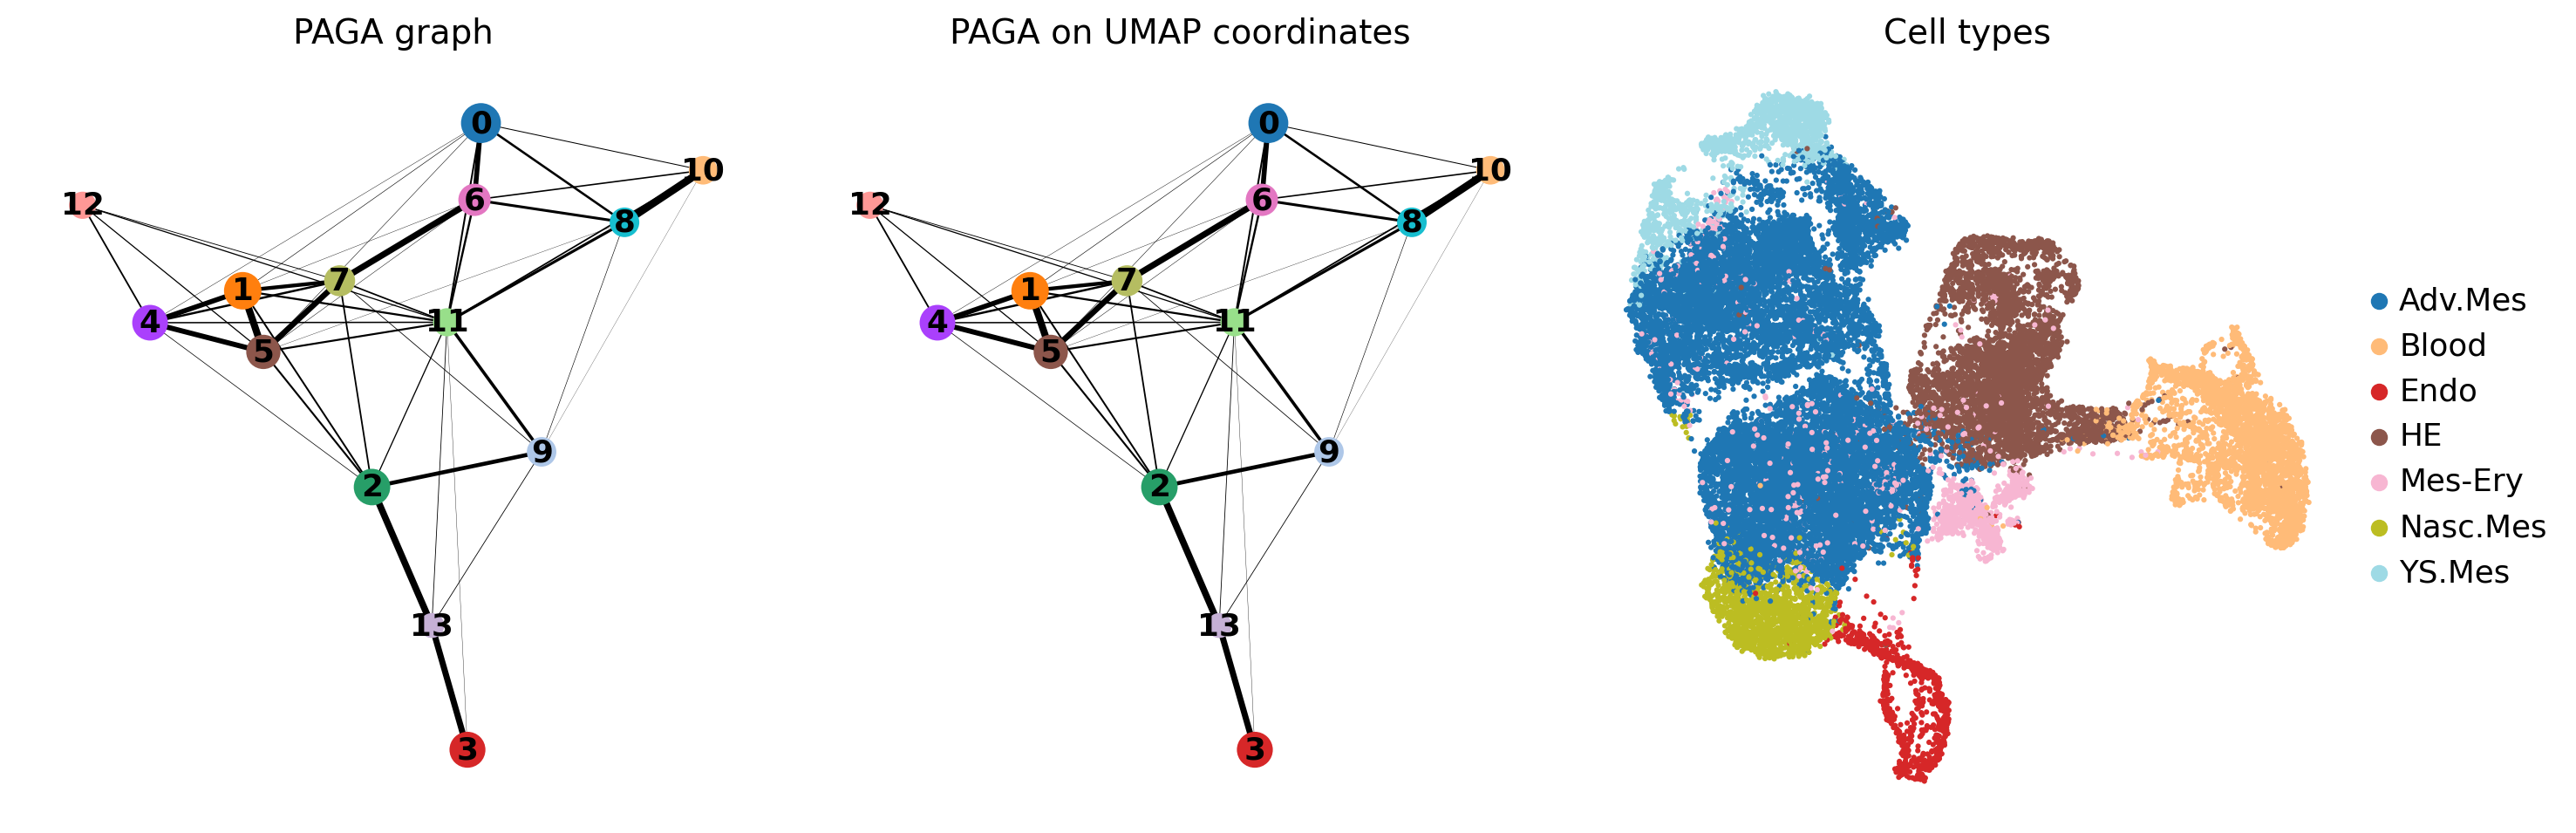


6. Computing Diffusion Pseudotime from Endo...
computing Diffusion Maps using n_comps=10(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9984059  0.997239   0.9942579  0.9918479  0.98688316
     0.986438   0.9858544  0.98328286 0.9828099 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)
Selected root cell: CELL296_N3-2
Root cell type: Endo
Root sample: d10
computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


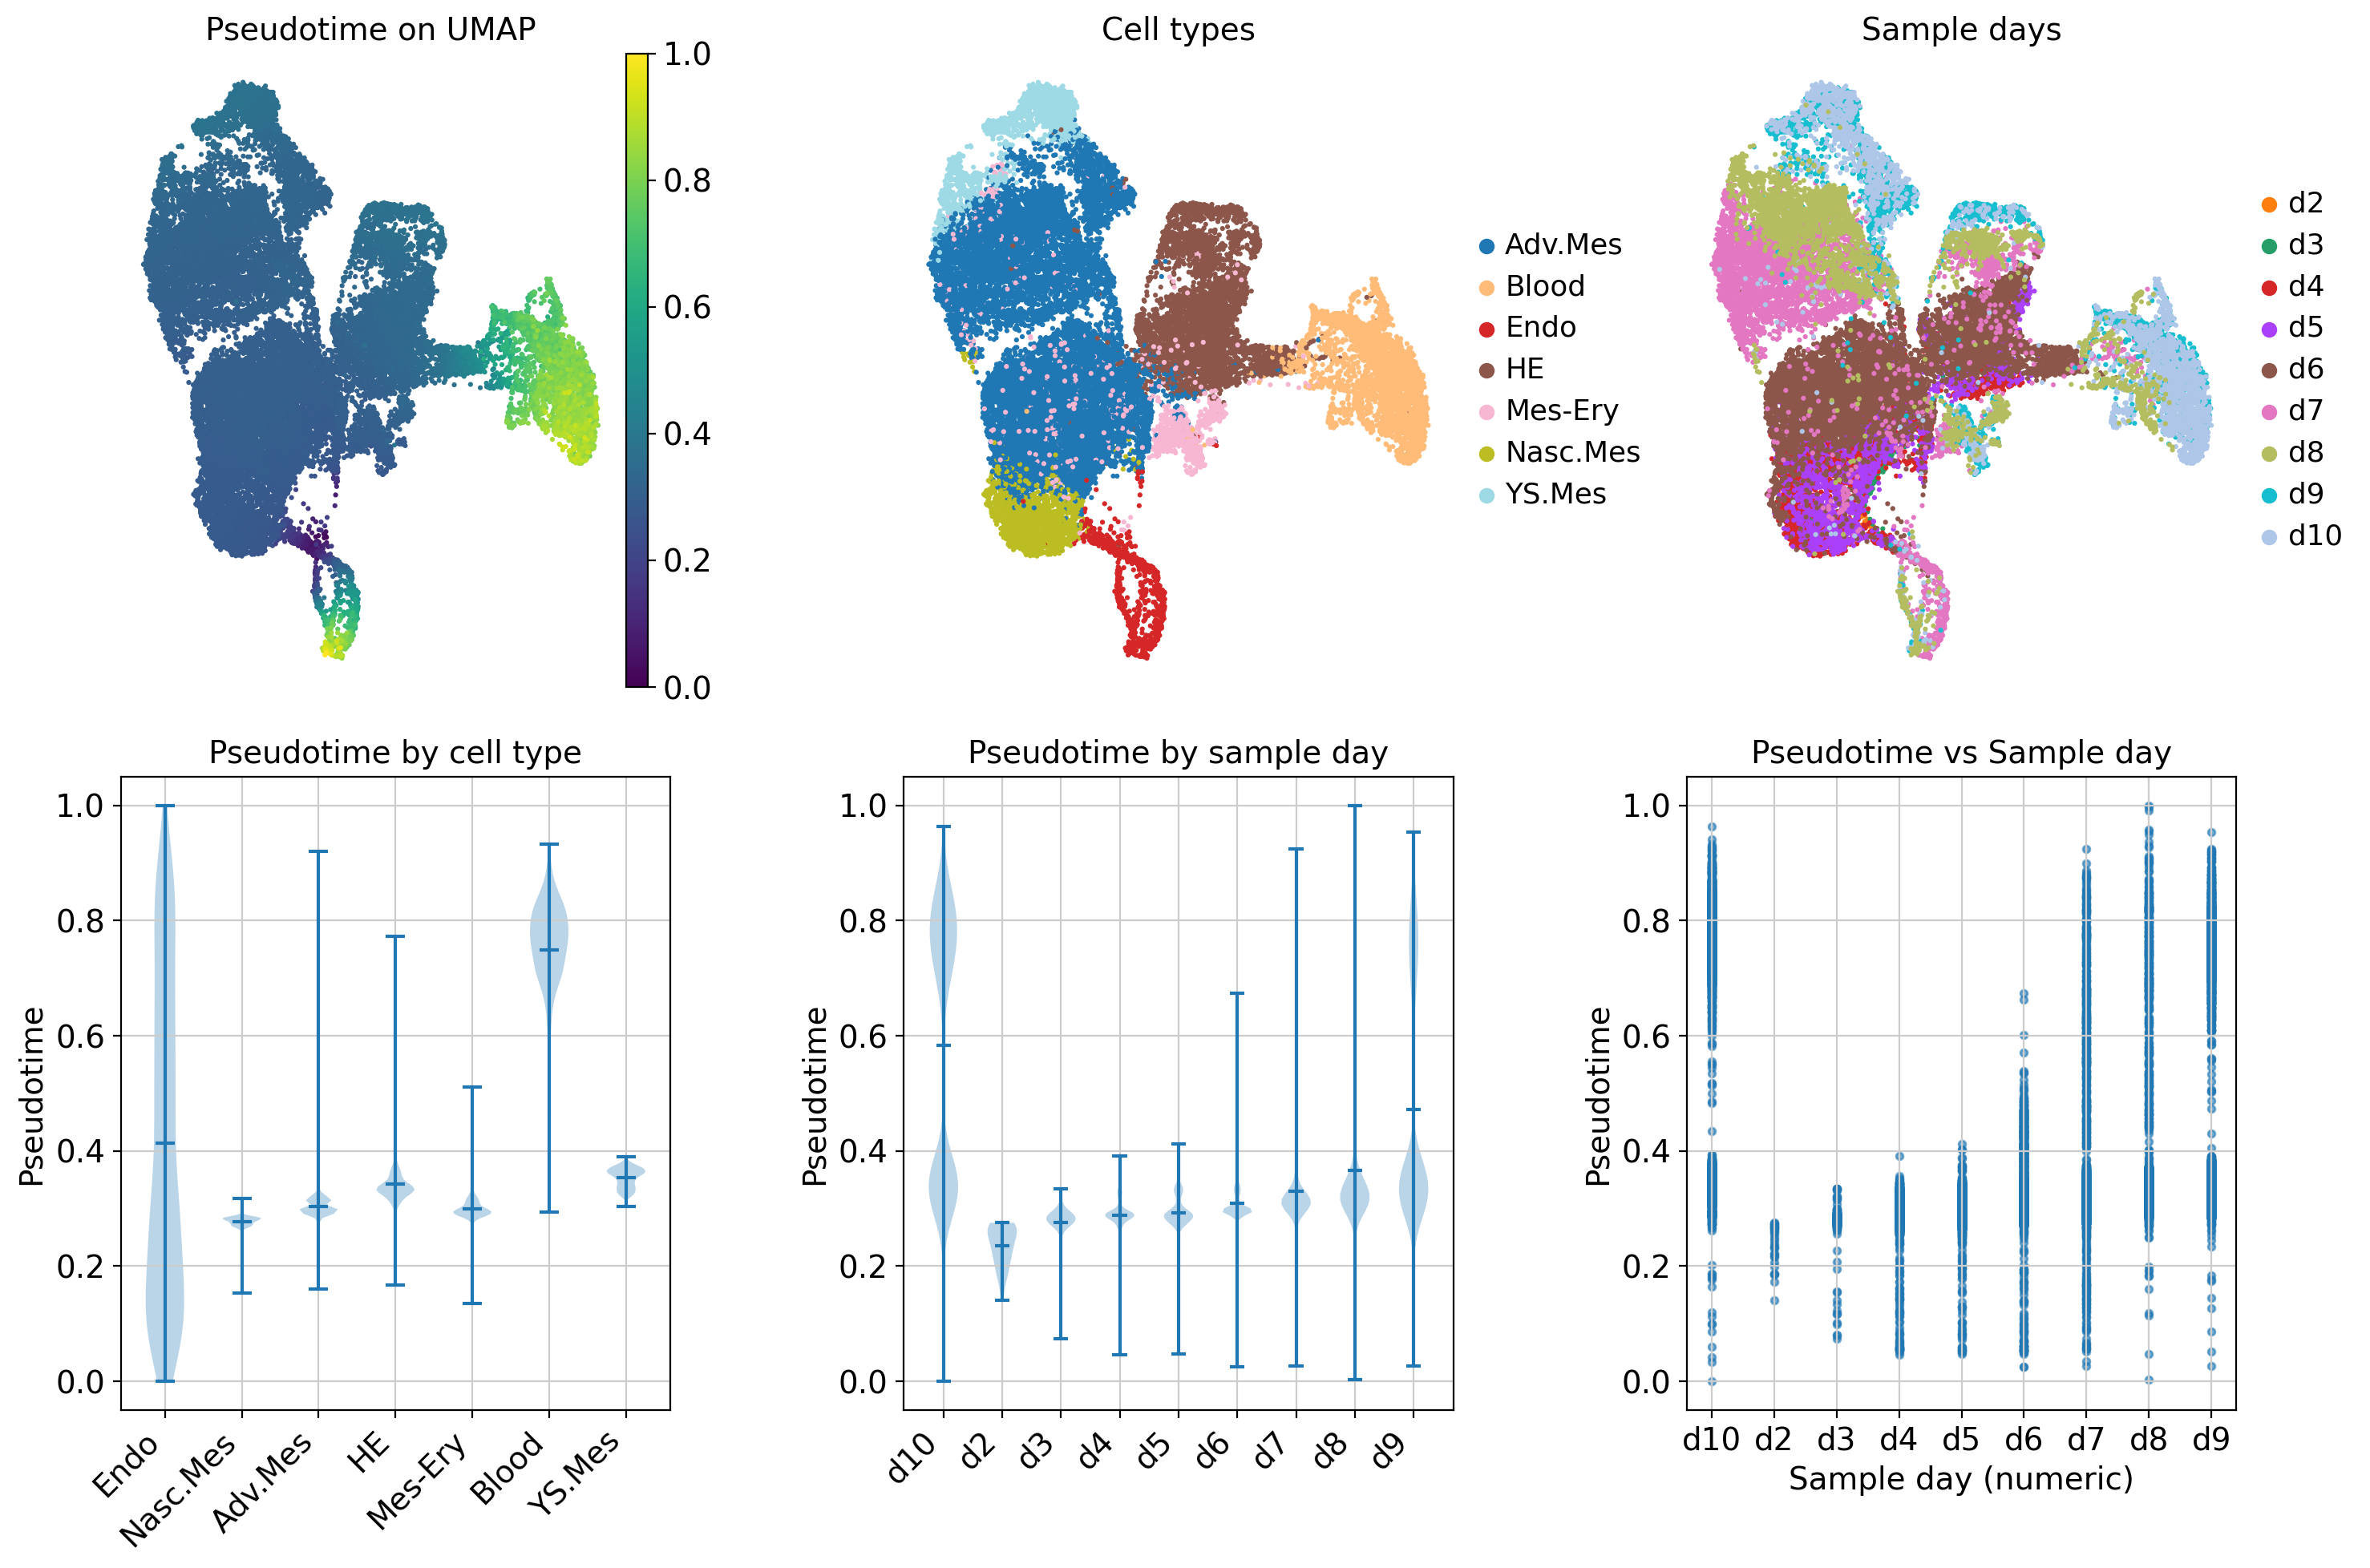


7. Analyzing genes along pseudotime...

Top 30 genes correlated with pseudotime:
             gene  correlation
92         S100A6     0.609757
1277      ARHGDIB     0.570512
93         S100A4     0.566033
1693       PECAM1     0.552843
1249         ESAM     0.528144
1846         CST3     0.507463
1150       IFITM2     0.505912
1915        TIMP3     0.498452
105        CRABP2     0.496344
976          HAS2     0.489326
629           F2R     0.476276
642         MEF2C     0.475814
497           PF4     0.472683
712        POU5F1     0.471090
237         LIMS1     0.469926
1595        CDH11     0.469360
39           TIE1     0.464964
1692        ICAM2     0.457999
1893        U2AF1     0.454953
1159         HBG2     0.450565
695        TUBB2B     0.446250
1186         CD82     0.445939
520         GRID2     0.442758
730   RPS10-NUDT3     0.441492
147         ZBED6     0.440257
827         PSMA2     0.437188
27       SH3BGRL3     0.436737
630         F2RL2     0.436374
1160         HBG1  

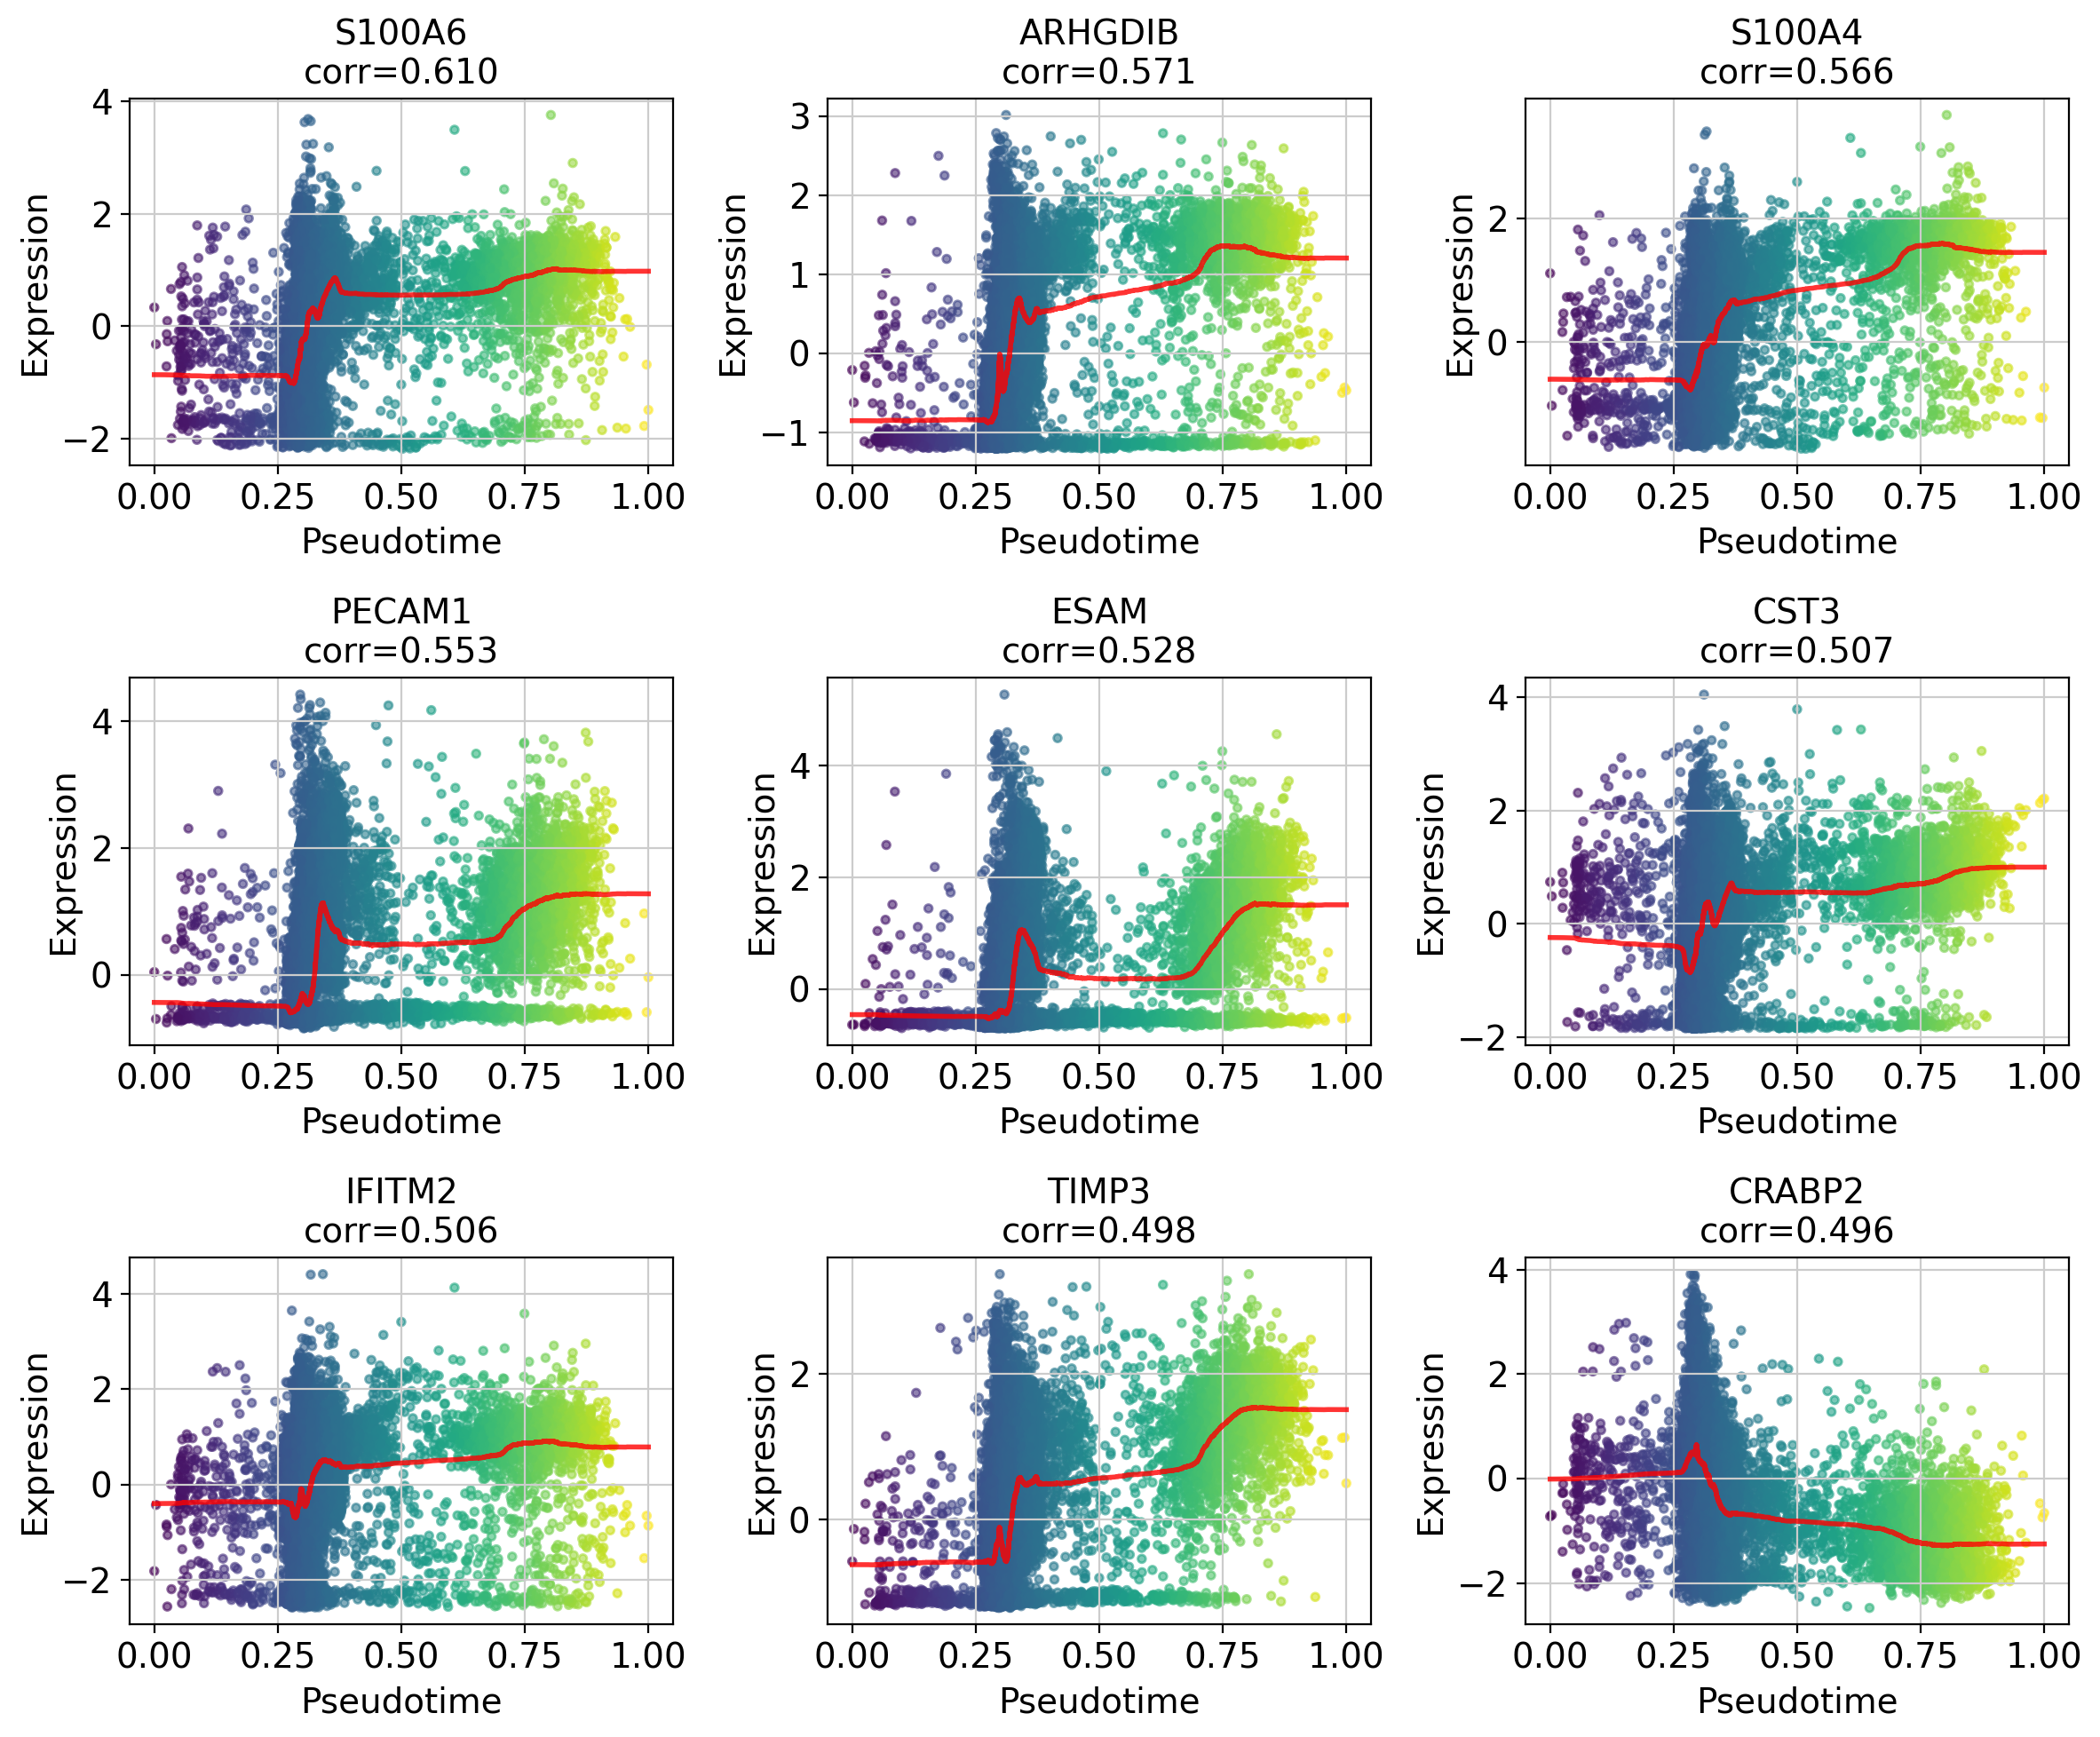


8. Creating trajectory visualizations...


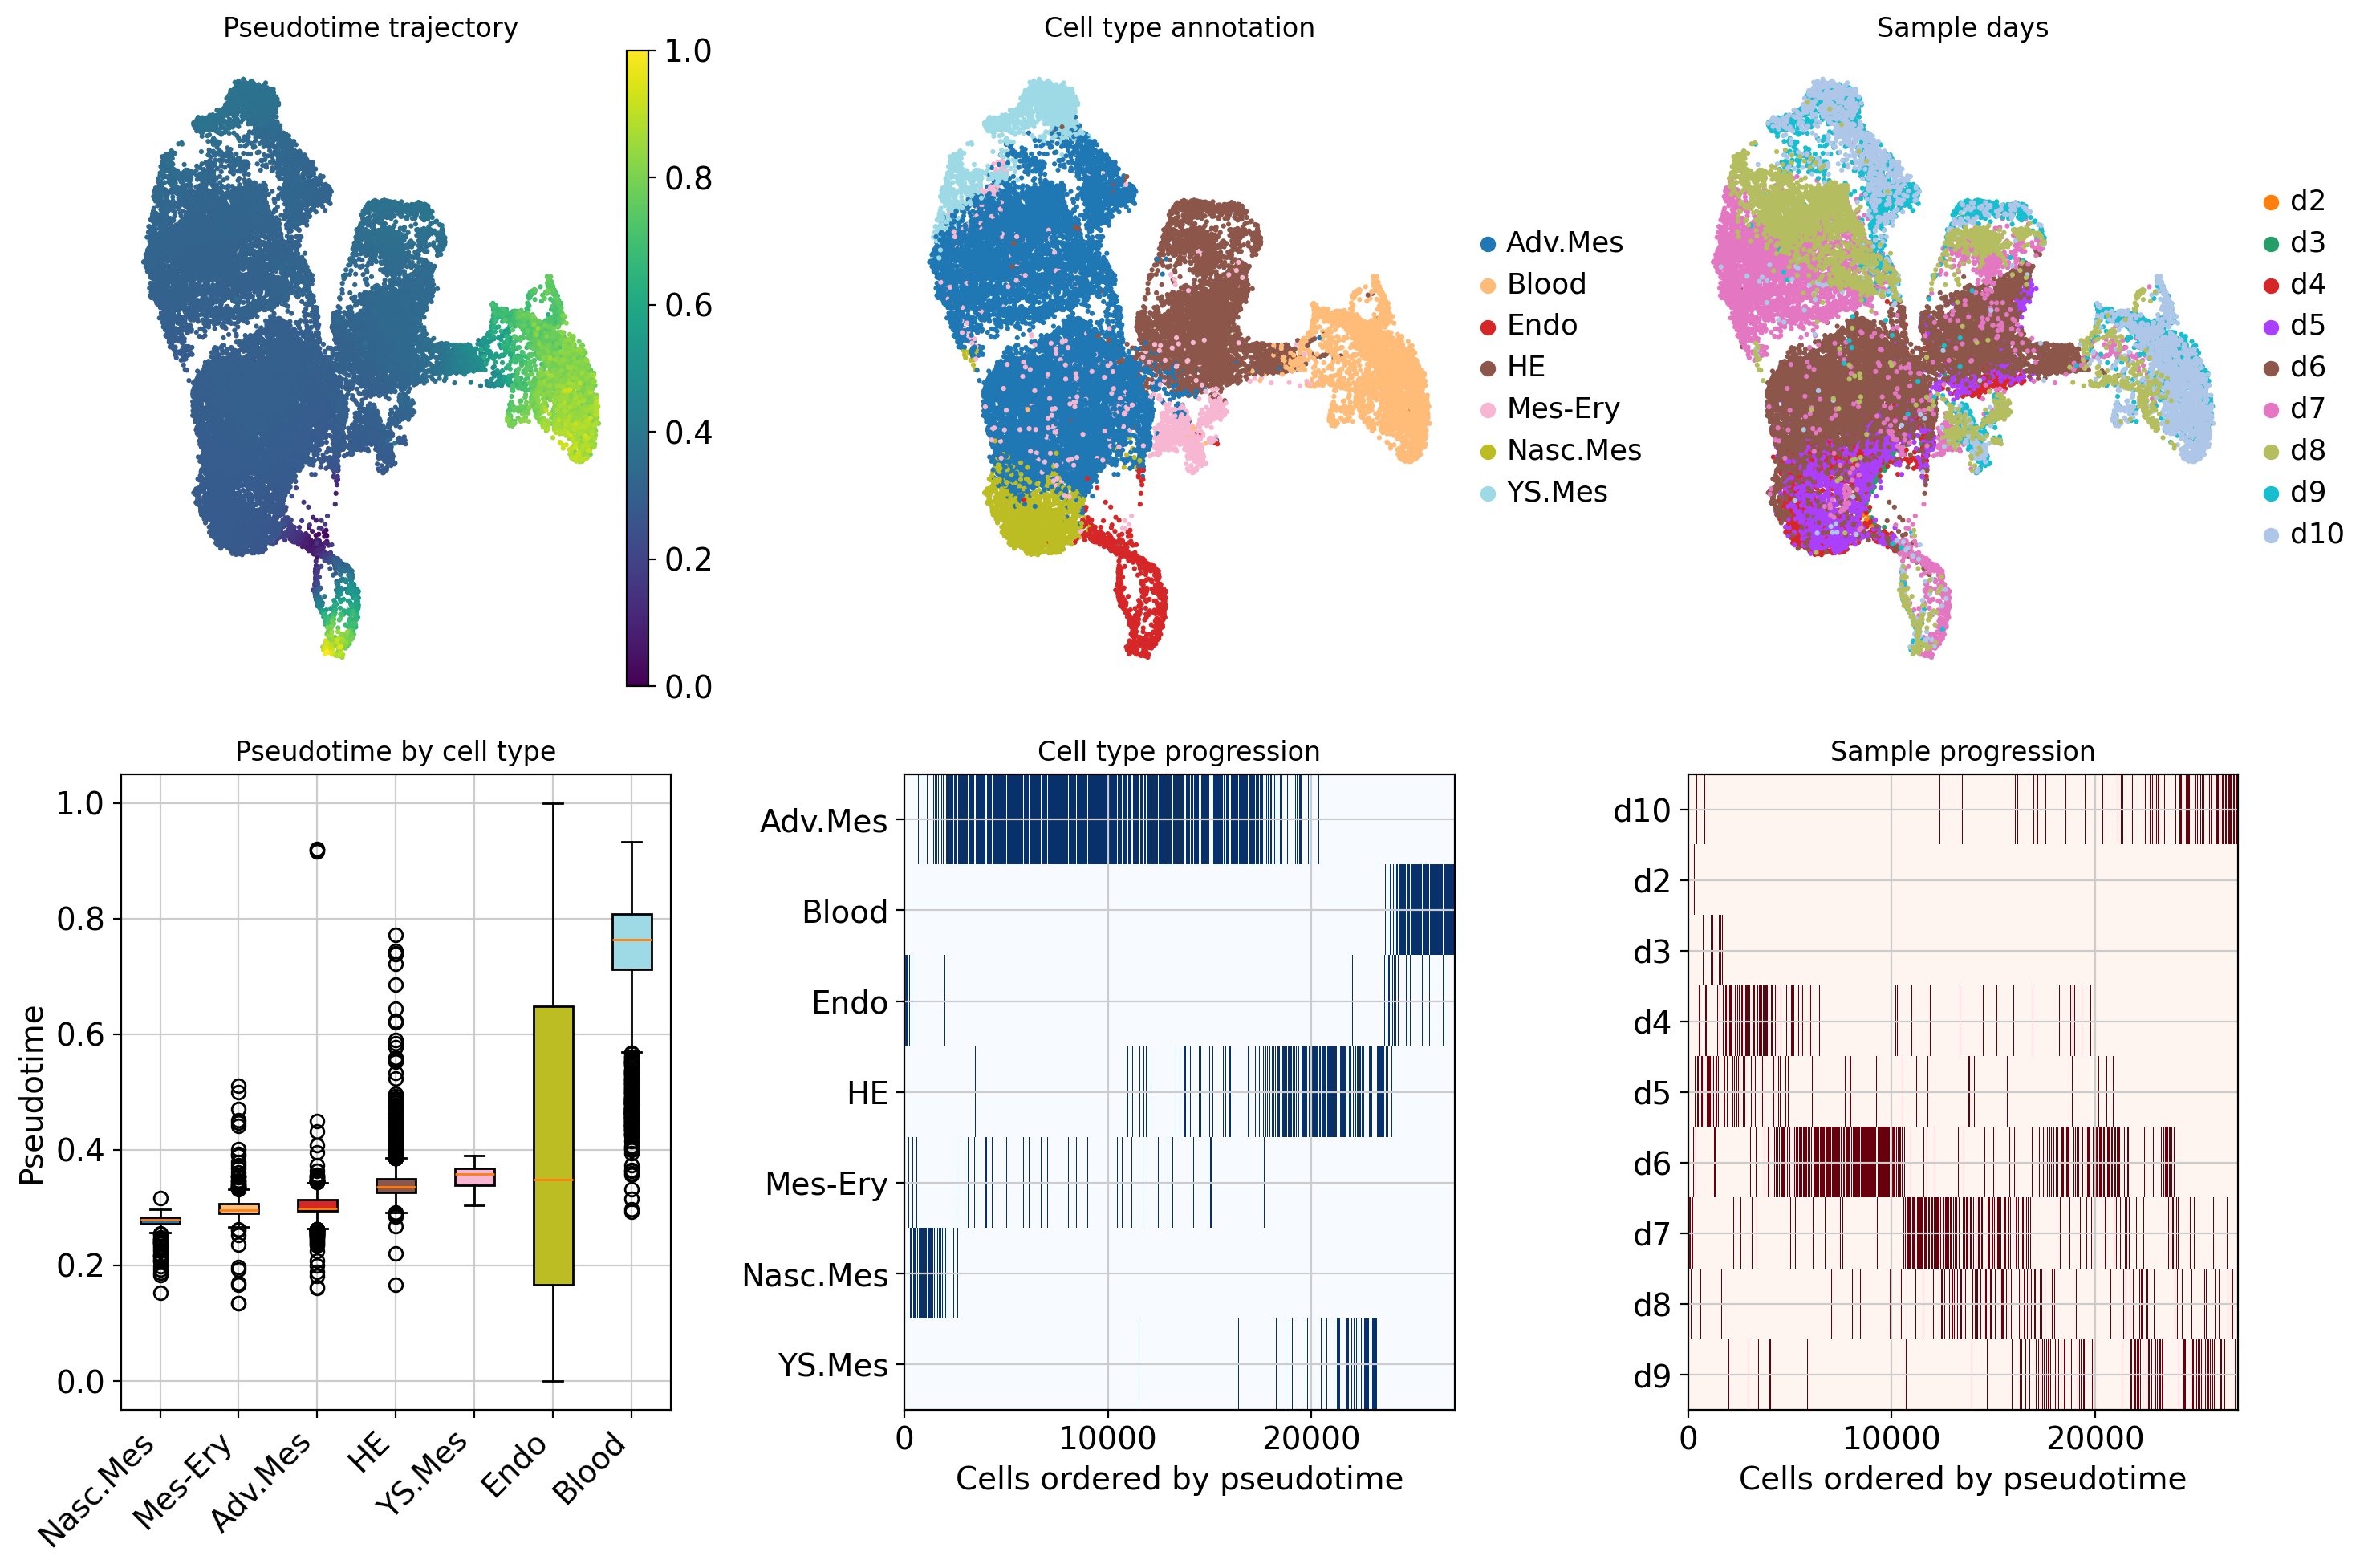

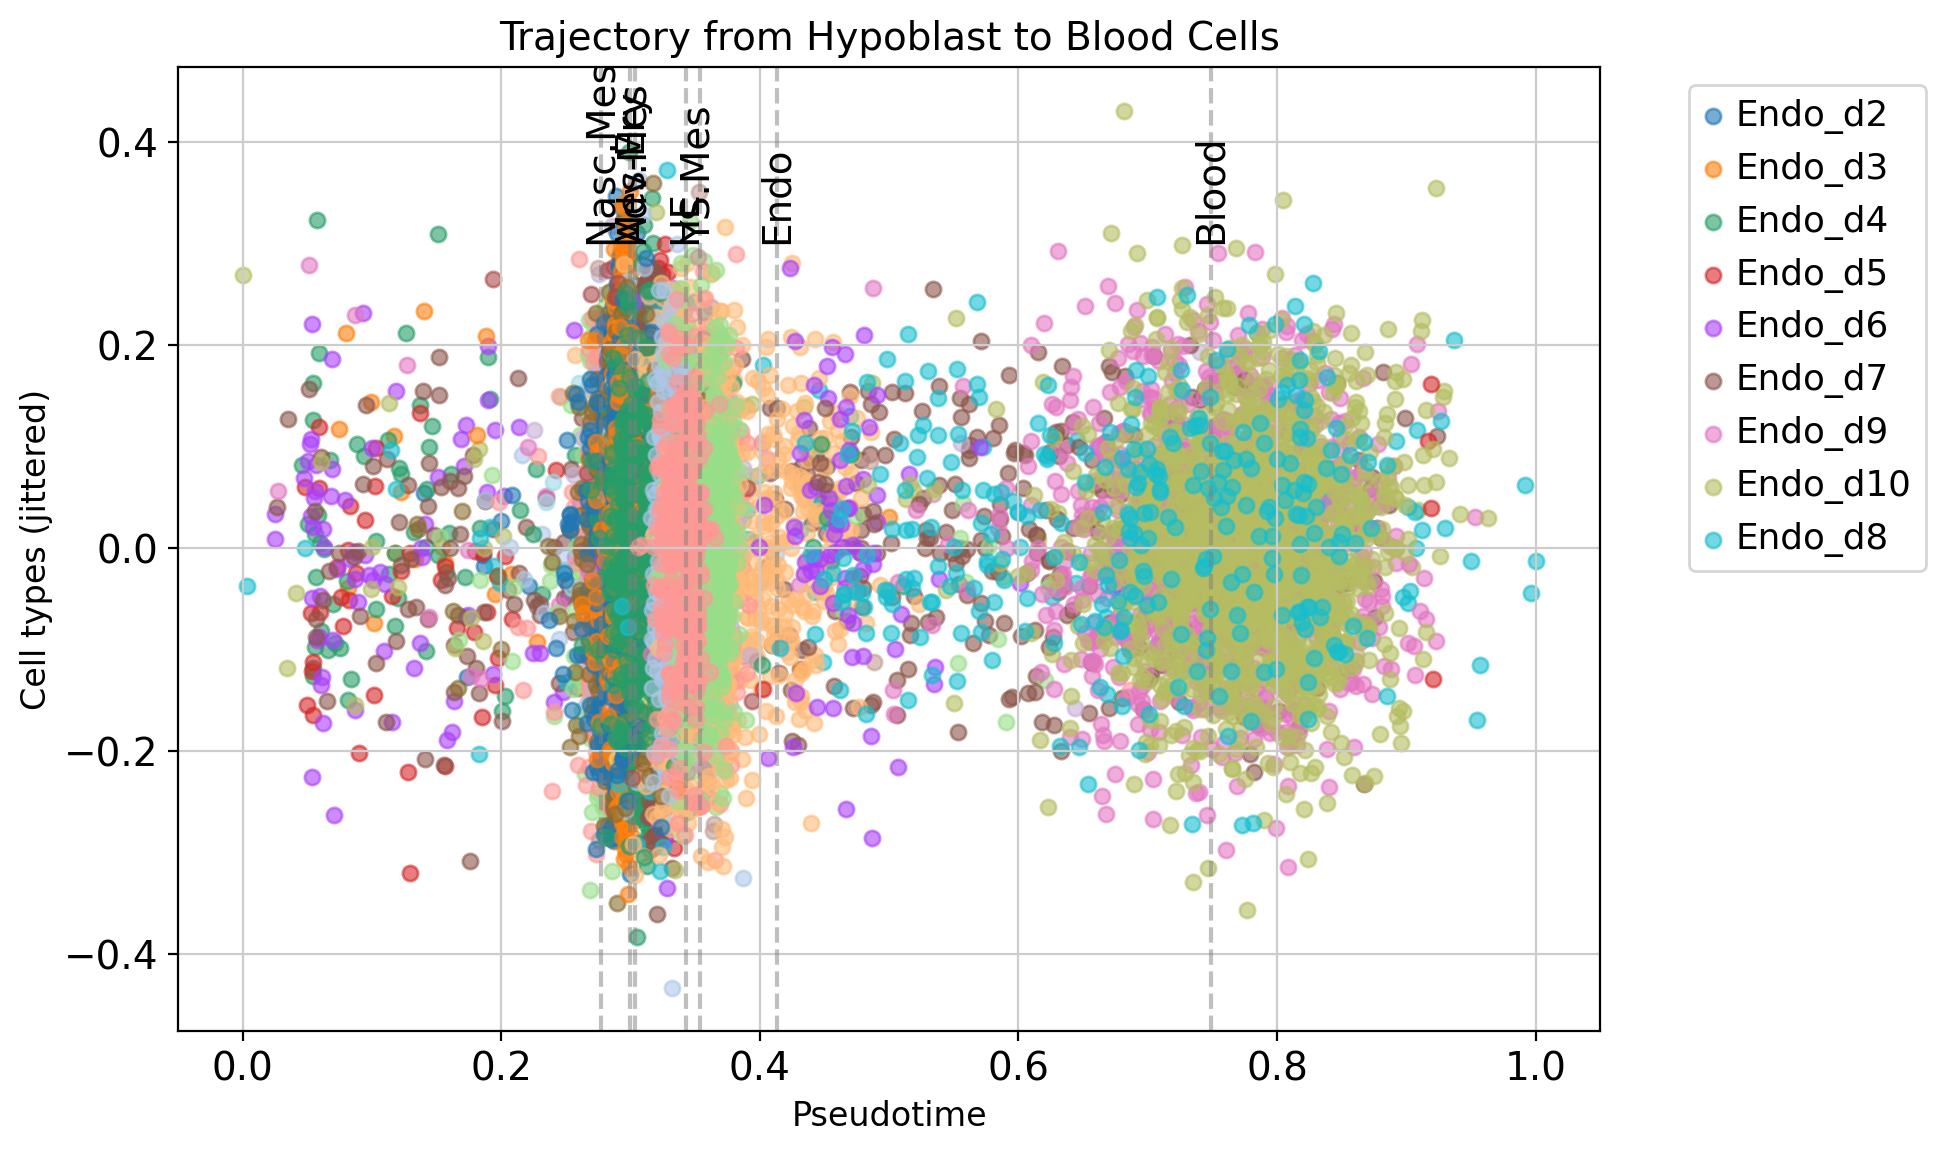


9. Saving results...

Analysis complete!

Key outputs saved:
- hypoblast_blood_trajectory_annotated.h5ad: Annotated AnnData object
- hypoblast_blood_trajectory_pseudotime.csv: Pseudotime values per cell
- hypoblast_blood_trajectory_gene_correlations.csv: Gene-pseudotime correlations
- hypoblast_blood_trajectory_summary.txt: Analysis summary


In [7]:
adata_subset, results = run_blood_trajectory_analysis(adata)